# Model Evaluation and Interpretation

This notebook focuses on model evaluation under class imbalance,
using resampling techniques and interpretability tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
df = pd.read_csv("dataset_model_ready.csv")

X = df.drop(columns=['Delta_class'])
y = df['Delta_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
categorical_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## Models with SMOTE

SMOTE is applied only on the training set to handle class imbalance.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
    ),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf'),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        random_state=42
    )
}

In [5]:
results = {}
conf_matrices = {}

for name, model in models.items():
    
    clf = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_F1': f1_score(y_test, y_pred, average='macro')
    }
    
    conf_matrices[name] = confusion_matrix(y_test, y_pred)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
                  precision    recall  f1-score   support

      Sottostima       0.17      0.78      0.29         9
      Sovrastima       0.29      0.71      0.41        28
Stima realistica       0.99      0.64      0.77       203

        accuracy                           0.65       240
       macro avg       0.48      0.71      0.49       240
    weighted avg       0.88      0.65      0.71       240


Random Forest
                  precision    recall  f1-score   support

      Sottostima       0.19      0.78      0.30         9
      Sovrastima       0.29      0.68      0.41        28
Stima realistica       0.98      0.67      0.79       203

        accuracy                           0.67       240
       macro avg       0.49      0.71      0.50       240
    weighted avg       0.87      0.67      0.73       240


SVM (RBF)
                  precision    recall  f1-score   support

      Sottostima       0.18      0.78      0.30         9
      Sovrastima  

In [6]:
results_df = pd.DataFrame(results).T.sort_values(
    by='Macro_F1',
    ascending=False
)

results_df

,Accuracy,Macro_F1
Random Forest,0.670833,0.501580
MLP,0.662500,0.497202
SVM (RBF),0.658333,0.492363
Logistic Regression,0.650000,0.489551


## Confusion Matrices

Confusion matrices highlight how each model handles minority classes.

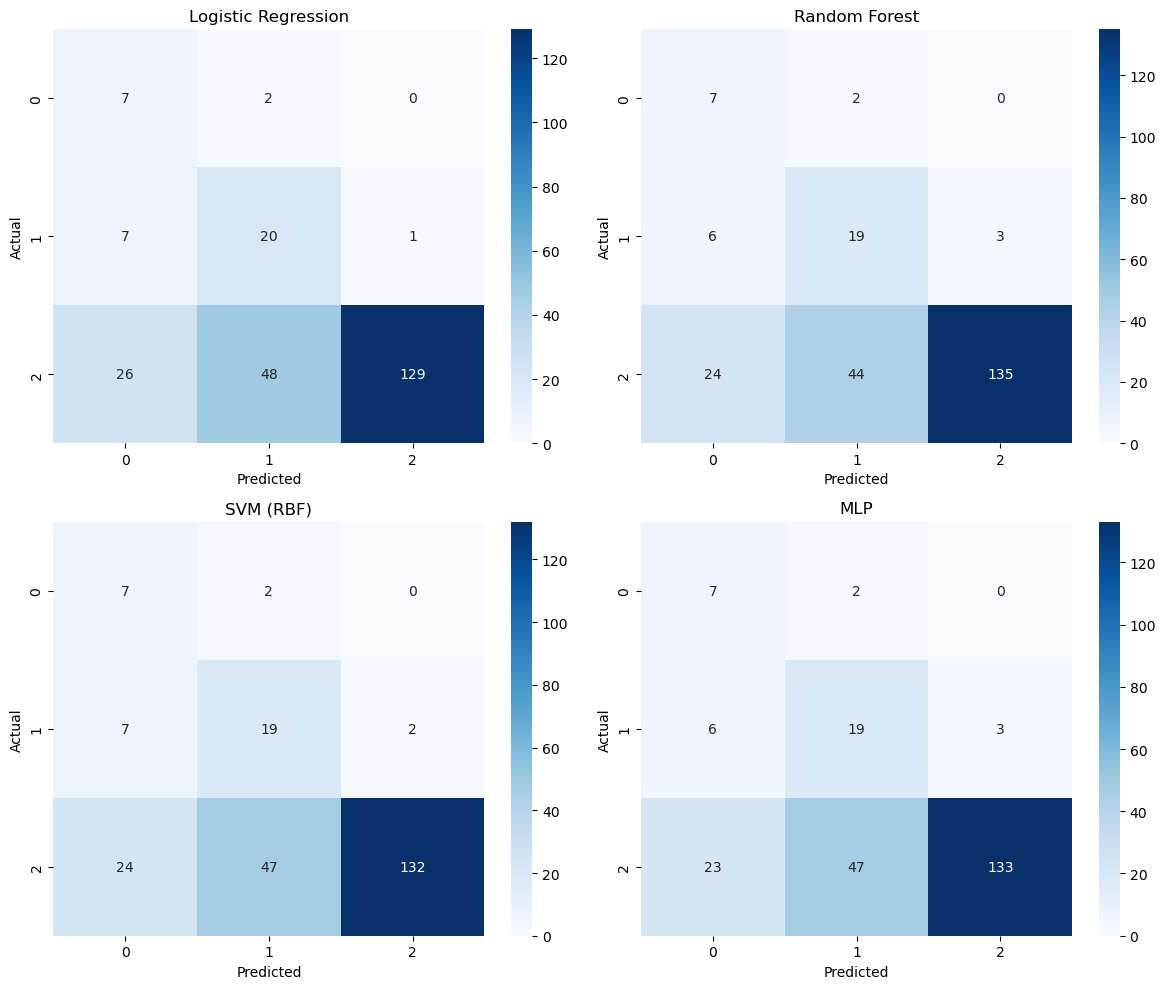

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Feature importance
We analyze feature importance from the Random Forest model.

In [8]:
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
3,Incentivi_bin_Zero,0.218813
1,Incentivi_bin_Basso,0.118211
15,Dipartimento_sweing,0.074917
7,wip_bin_Zero,0.064525
18,Sabato_0,0.050385
19,Sabato_1,0.049561
16,FineMese_0,0.046563
17,FineMese_1,0.042175
14,Dipartimento_finishing,0.041960
12,NumeroLavoratori_bin_Medio,0.041103


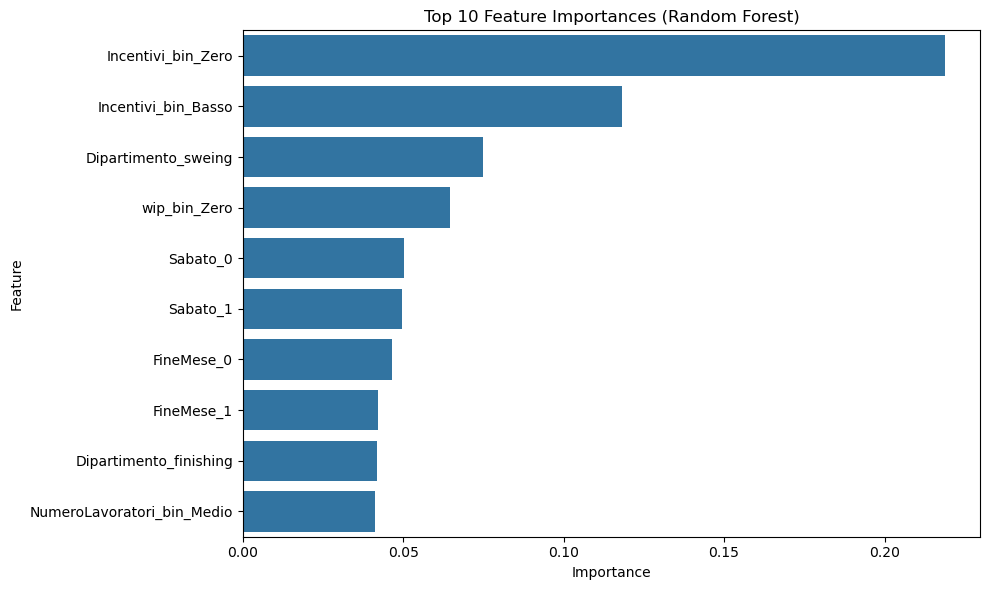

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp.head(10),
    y='Feature',
    x='Importance'
)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

## Final considerations

- SMOTE improves Macro-F1 across all models
- Tree-based models remain the most robust
- Calendar and workload-related features are key drivers
- The pipeline is suitable for real-world deployment